<a href="https://colab.research.google.com/github/WSmithDR/machine-learning-project/blob/main/Proyecto_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Datos atípicos

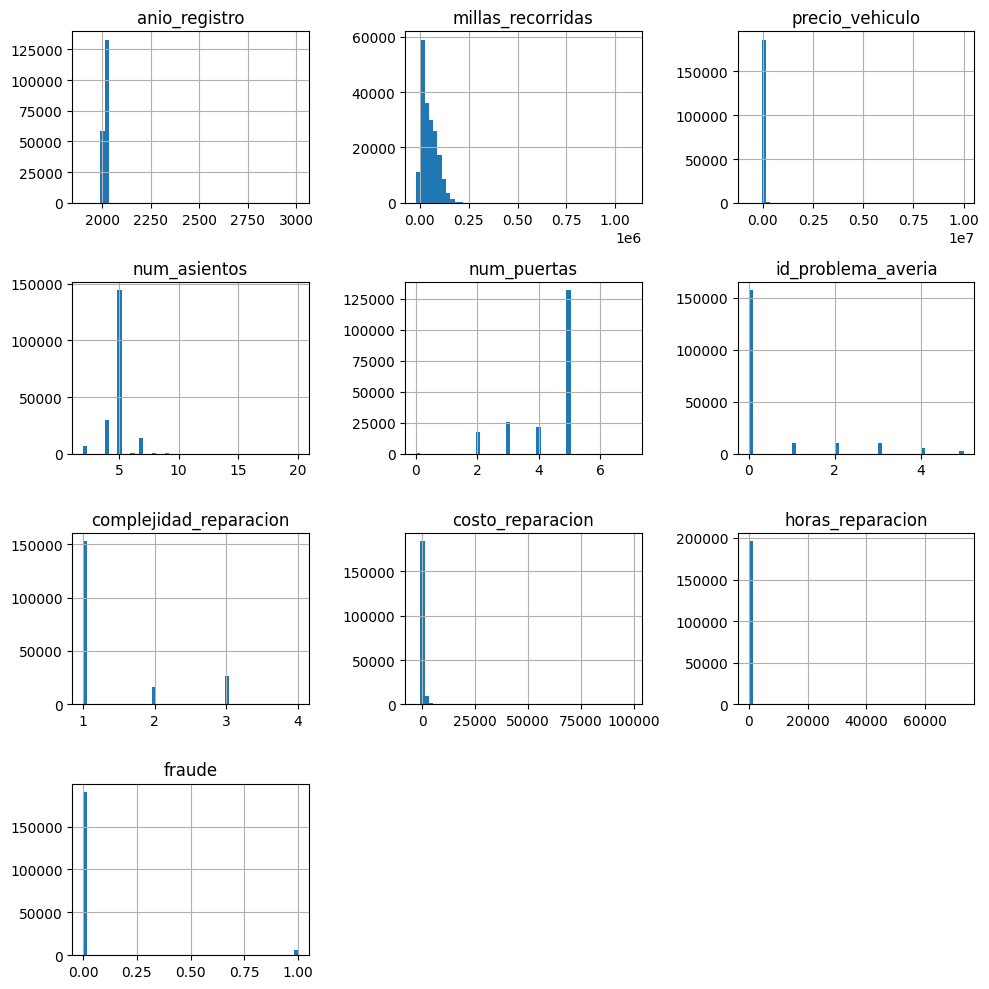

In [18]:
#distribución del dataset train
df_train.hist(bins=50, figsize=(10,10))
plt.tight_layout()
plt.show()

In [19]:
df_train.columns

Index(['marca', 'modelo', 'color', 'anio_registro', 'tipo_vehiculo',
       'millas_recorridas', 'tamanio_motor', 'transmision', 'tipo_combustible',
       'precio_vehiculo', 'num_asientos', 'num_puertas', 'problema_averia',
       'id_problema_averia', 'fecha_averia', 'complejidad_reparacion',
       'costo_reparacion', 'horas_reparacion', 'fecha_reparacion', 'fraude'],
      dtype='object')

In [20]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196429 entries, 0 to 196428
Data columns (total 20 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   marca                   196429 non-null  object 
 1   modelo                  177768 non-null  object 
 2   color                   191581 non-null  object 
 3   anio_registro           191599 non-null  float64
 4   tipo_vehiculo           196429 non-null  object 
 5   millas_recorridas       193664 non-null  float64
 6   tamanio_motor           195482 non-null  object 
 7   transmision             196429 non-null  object 
 8   tipo_combustible        196429 non-null  object 
 9   precio_vehiculo         186867 non-null  float64
 10  num_asientos            196429 non-null  float64
 11  num_puertas             196429 non-null  float64
 12  problema_averia         196429 non-null  object 
 13  id_problema_averia      196429 non-null  int64  
 14  fecha_averia        

In [21]:
df_train.describe()

,anio_registro,millas_recorridas,precio_vehiculo,num_asientos,num_puertas,id_problema_averia,complejidad_reparacion,costo_reparacion,horas_reparacion,fraude
count,191599.000000,1.936640e+05,1.868670e+05,196429.000000,196429.000000,196429.000000,196429.000000,196429.000000,196429.000000,196429.000000
mean,2012.678208,4.867635e+04,1.396373e+04,4.935590,4.358593,0.498511,1.366855,342.198345,12.427234,0.030937
std,5.006846,4.004901e+04,3.307734e+04,1.072501,1.031904,1.131135,0.726668,1057.977648,306.762296,0.173149
min,1900.000000,-1.991700e+04,-6.967960e+05,2.000000,0.000000,0.000000,1.000000,-2989.000000,-28.000000,0.000000
25%,2009.000000,1.464700e+04,4.795000e+03,5.000000,4.000000,0.000000,1.000000,35.570000,1.000000,0.000000
50%,2014.000000,4.000000e+04,8.999000e+03,5.000000,5.000000,0.000000,1.000000,105.430000,2.000000,0.000000
75%,2016.000000,7.557125e+04,1.697000e+04,5.000000,5.000000,0.000000,1.000000,288.750000,4.000000,0.000000
max,3010.000000,1.080000e+06,9.999999e+06,20.000000,7.000000,5.000000,4.000000,98690.116330,73134.610091,1.000000


In [22]:
df_train_n = df_train.copy()

### Anio_registro

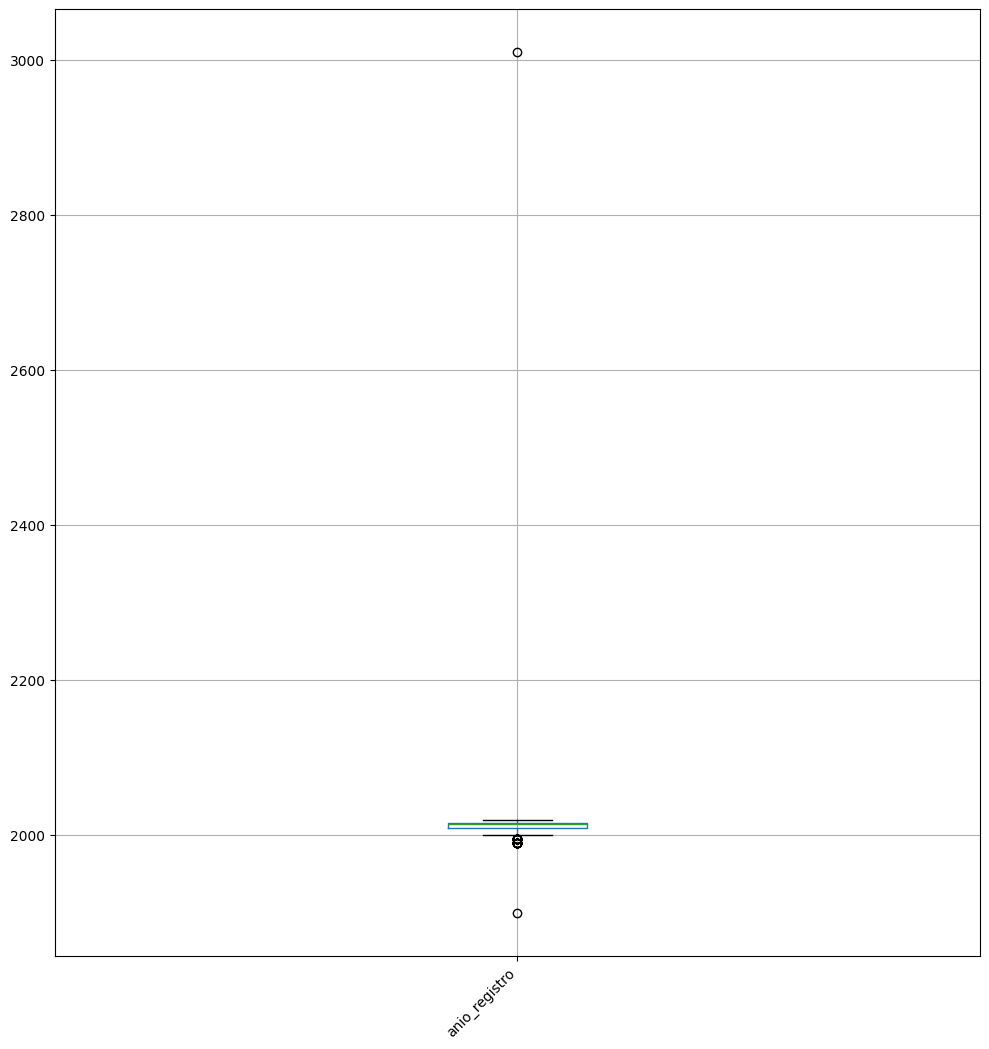

In [23]:
#visualización de valores atípicos del dataset train
df_train[['anio_registro']].boxplot(figsize=(10, 10))
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

In [24]:
#visualización de valores atípicos del dataset train
df_train[['anio_registro']].groupby('anio_registro').size()

anio_registro
1900.0        1
1990.0       12
1995.0       19
2000.0      496
2001.0     1163
2002.0     1962
2003.0     2449
2004.0     3797
2005.0     4346
2006.0     6919
2007.0     8032
2008.0     9449
2009.0     9267
2010.0    10735
2011.0    10953
2012.0    12147
2013.0    12914
2014.0    15766
2015.0    20862
2016.0    15951
2017.0    19104
2018.0    12591
2019.0    12663
3010.0        1
dtype: int64

In [25]:
#analizamos las caracteristica que tiene el carro con el anio aberrante
df_train[df_train['anio_registro']==1900.0].head()

,marca,modelo,color,anio_registro,tipo_vehiculo,millas_recorridas,tamanio_motor,transmision,tipo_combustible,precio_vehiculo,num_asientos,num_puertas,problema_averia,id_problema_averia,fecha_averia,complejidad_reparacion,costo_reparacion,horas_reparacion,fecha_reparacion,fraude
23716,Vauxhall,Corsa,Grey,1900.0,Hatchback,NaN,1.4L,Manual,Petrol,8500.0,12.0,0.0,Gear Box Issue,0,2018-05-04,1,626.373971,475.223492,2018-06-01,1


In [26]:
#filtramos el df con las mismas caracteristicas que tiene el carro con el anio aberrante
df_train[(df_train['marca']=='Vauxhall') & (df_train['modelo']=='Corsa') & (df_train['tamanio_motor']=='1.4L') & (df_train['precio_vehiculo']==8500.0)& (df_train['color']=='Grey')].head(23)

,marca,modelo,color,anio_registro,tipo_vehiculo,millas_recorridas,tamanio_motor,transmision,tipo_combustible,precio_vehiculo,num_asientos,num_puertas,problema_averia,id_problema_averia,fecha_averia,complejidad_reparacion,costo_reparacion,horas_reparacion,fecha_reparacion,fraude
23716,Vauxhall,Corsa,Grey,1900.0,Hatchback,NaN,1.4L,Manual,Petrol,8500.0,12.0,0.0,Gear Box Issue,0,2018-05-04,1,626.373971,475.223492,2018-06-01,1
75841,Vauxhall,Corsa,Grey,2016.0,Hatchback,10945.0,1.4L,Manual,Petrol,8500.0,5.0,5.0,Transmission Issue,1,2018-04-20,1,105.500000,4.000000,2018-04-21,0


In [27]:
#reemplazamos el anio de otro carro similar que tiene caracteristicas similares
df_train_n.loc[df_train_n['anio_registro'] == 1900.0, 'anio_registro'] = 2016.0


In [28]:
#analizamos las caracteristica que tiene el carro con el anio aberrante
df_train[df_train['anio_registro']==3010.0].head()

,marca,modelo,color,anio_registro,tipo_vehiculo,millas_recorridas,tamanio_motor,transmision,tipo_combustible,precio_vehiculo,num_asientos,num_puertas,problema_averia,id_problema_averia,fecha_averia,complejidad_reparacion,costo_reparacion,horas_reparacion,fecha_reparacion,fraude
166214,BMW,7 Series,Grey,3010.0,Wood,-2038.0,999.0L,Hybrid,Hydrogen,-182067.0,12.0,0.0,Excessive Emissions,0,2018-04-15,1,-418.0,1.0,2018-04-15,1


In [29]:
#filtramos el df con las mismas caracteristicas que tiene el carro con el anio aberrante
# df_train[(df_train['marca']=='BMW') & (df_train['modelo']=='7 Series') & (df_train['tamanio_motor']=='999.0L')& (df_train['color']=='Grey')].head(23)
df_train[(df_train['marca']=='BMW') & (df_train['modelo']=='7 Series') & (df_train['color']=='Grey')].groupby('anio_registro').size().sort_values()

anio_registro
3010.0    1
2003.0    2
2006.0    2
2005.0    2
2008.0    3
2010.0    3
2015.0    3
2007.0    3
2012.0    3
2013.0    4
2011.0    4
2009.0    6
2017.0    6
2014.0    6
2018.0    8
2016.0    8
2019.0    9
dtype: int64

In [30]:
#reemplazamos el anio de otro carro similar que tiene caracteristicas similares
df_train_n.loc[df_train_n['anio_registro'] == 3010.0, 'anio_registro'] = 2019.0

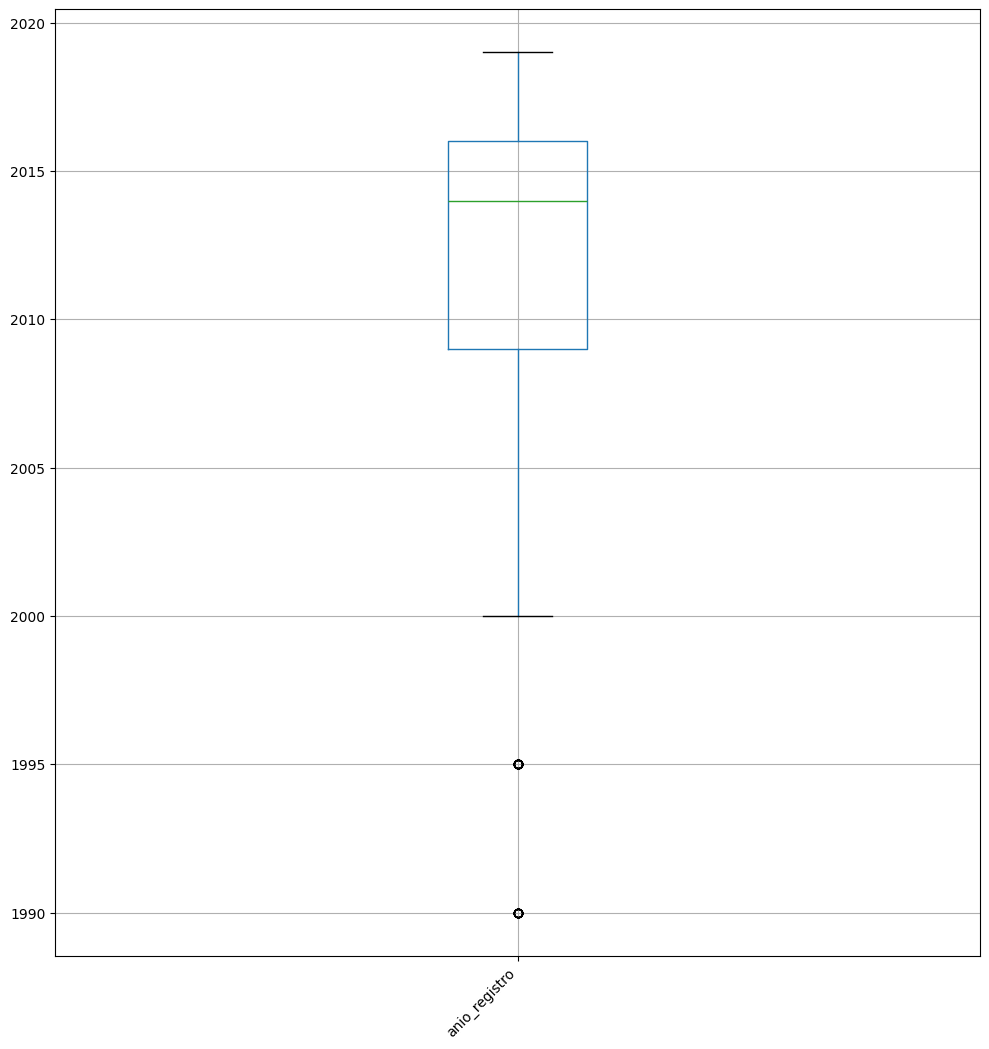

In [31]:
#visualización de valores atípicos del dataset limpio
df_train_n[['anio_registro']].boxplot(figsize=(10, 10))
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

## millas_recorridas

## precio_vehiculo


## costo_reparacion

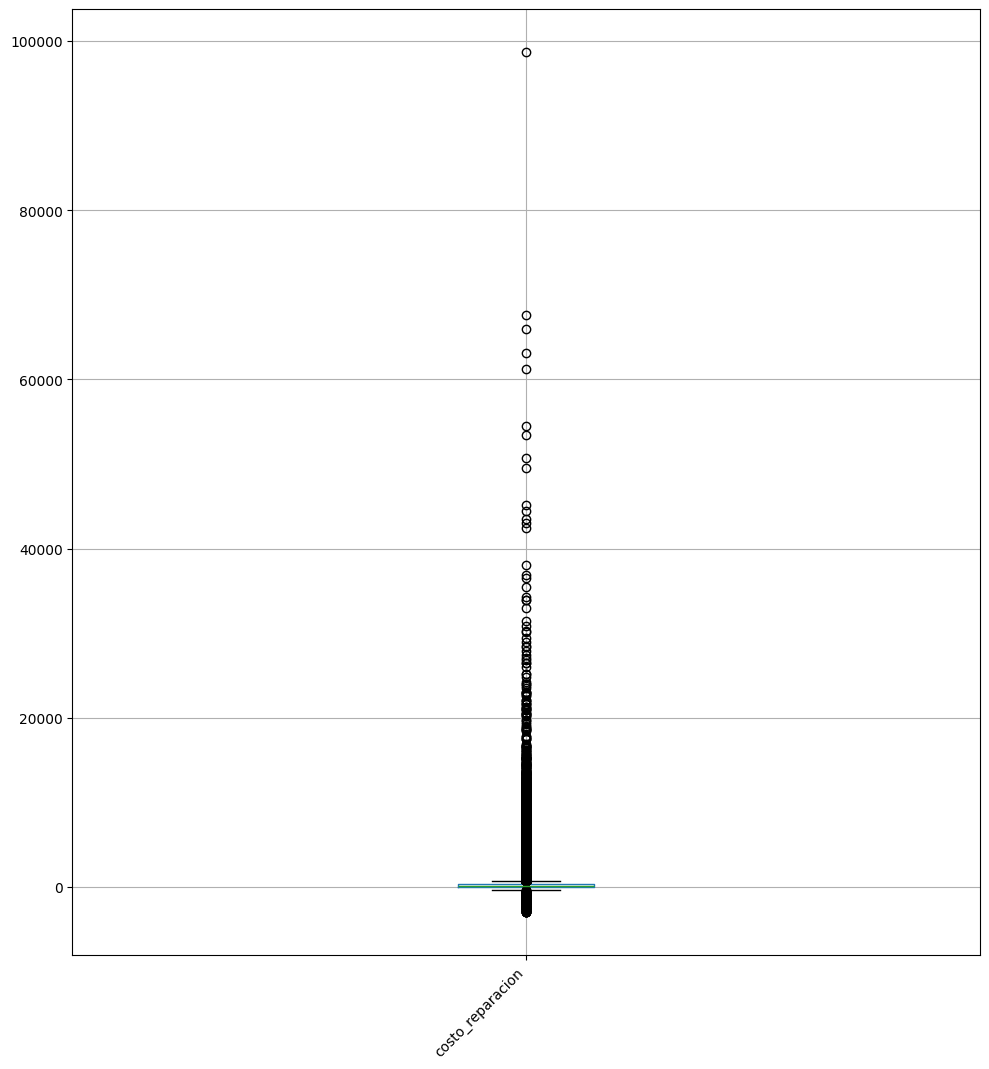

In [32]:
#visualización de valores atípicos del dataset train
df_co = df_train[['costo_reparacion']]
# df_co[df_train['costo_reparacion'] < 0].boxplot(figsize=(10, 10))
df_train[['costo_reparacion']].boxplot(figsize=(10, 10))
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

In [33]:
#datos que tienen ruido, no deberían estar con valor negativo
df_train[df_train['costo_reparacion'] < 0].groupby(['marca','modelo','anio_registro']).size()

marca  modelo                 anio_registro
BMW    6 Series               2005.0            9
                              2009.0            1
                              2010.0            1
                              2011.0            3
                              2012.0            6
                              2013.0            5
                              2014.0            4
       6 Series Gran Coupe    2012.0            1
                              2013.0            5
                              2014.0            9
                              2015.0            6
                              2016.0            1
                              2017.0            7
                              2018.0            2
       6 Series Gran Turismo  2017.0            6
       7 Series               2002.0            1
                              2003.0            1
                              2009.0            2
                              2010.0            4
      

In [34]:
#analizamos las caracteristica que tiene el carro con el anio aberrante
df_train[df_train['costo_reparacion'] < 0].head(137)

,marca,modelo,color,anio_registro,tipo_vehiculo,millas_recorridas,tamanio_motor,transmision,tipo_combustible,precio_vehiculo,num_asientos,num_puertas,problema_averia,id_problema_averia,fecha_averia,complejidad_reparacion,costo_reparacion,horas_reparacion,fecha_reparacion,fraude
2903,BMW,6 Series Gran Turismo,White,2017.0,Hatchback,5650.0,3.0L,Automatic,Diesel,-33329.0,5.0,5.0,Electrical Issue,5,2018-03-20,1,-700.0,3.0,2018-03-20,1
4266,BMW,6 Series Gran Coupe,Black,2018.0,Coupe,15.0,3.0L,Automatic,Diesel,NaN,5.0,4.0,Electrical Issue,1,2018-03-25,1,-2719.0,2.0,2018-03-25,1
5714,BMW,Alpina D3,Blue,2007.0,Saloon,154286.0,2.0L,Manual,Diesel,-480465.0,5.0,0.0,Alternator Failing,0,2018-01-07,1,-1242.0,2.0,2018-01-07,1
5720,BMW,6 Series Gran Turismo,Grey,2017.0,Hatchback,5651.0,3.0L,Automatic,Diesel,-34768.0,5.0,5.0,Starter Motor Issue,0,2018-02-20,1,-1696.0,3.0,2018-02-20,1
8535,BMW,6 Series Gran Coupe,Red,2015.0,Coupe,11018.0,3.0L,Automatic,Petrol,-233553.0,4.0,4.0,Windscreen Crack,0,2018-02-21,1,-1096.0,1.0,2018-02-21,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182174,BMW,6 Series Gran Coupe,White,2014.0,Coupe,45222.0,3.0L,Automatic,Diesel,-20904.0,5.0,4.0,Electrical Issue,5,2018-03-07,1,-2182.0,3.0,2018-03-07,1
183782,BMW,7 Series,Black,2012.0,Saloon,54000.0,3.0L,Automatic,Diesel,-68783.0,5.0,4.0,Gear Box Issue,0,2018-03-15,1,-1971.0,2.0,2018-03-15,1
184604,BMW,6 Series Gran Coupe,White,2015.0,Coupe,32200.0,3.0L,Automatic,Diesel,-380331.0,4.0,4.0,Windscreen Crack,0,2017-06-25,1,-1719.0,1.0,2017-06-25,1
184793,BMW,6 Series Gran Coupe,Black,2017.0,Coupe,9692.0,3.0L,Automatic,Diesel,-17360.0,5.0,4.0,Radiator Leaking,0,2018-03-09,1,-677.0,2.0,2018-03-09,1


## horas_reparacion